# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** Muhammad Zulfikar
- **Email:** masfikar92@gmail.com(CDCC466D6Y1391@student.devacademy.id)
- **ID Dicoding:** CDCC466D6Y1391

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** pada bulan apa penyewaan sepeda paling tinggi dan paling rendah
- **Pertanyaan 2:** seberapa berefek penyewaan sepeda terhadap temperatur yang dirasakan oleh tubuh
- ...

## Import Semua Packages/Library yang Digunakan

In [258]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [259]:
df_day = pd.read_csv('day.csv')
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [260]:
df_hour = pd.read_csv('hour.csv')
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)
dibuktikan dari kolom hr
- dataframe day untuk penghasilan sewa perharinya
- dataframe hour untuk penghasilan sewa perjamnya

### Assessing Data

#### Identifying ... problem

In [261]:
df_day.isna().sum()
df_day.dtypes

,0
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64
temp,float64


In [262]:
df_hour.isna().sum()
df_hour.dtypes

,0
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
hr,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64


**Steps to Take:**
- mengecek missing value
- mengecek type data

**Insight:** (Opsional)
- tidak ada missing value
- type data integer

### Cleaning Data

#### Fixing ... problem

In [263]:
df_day['dteday'] = pd.to_datetime(df_day['dteday'])
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])

kolom = ['season','yr','mnth','holiday','weekday','workingday','weathersit']

for col in kolom:
    df_day[col]=df_day[col].astype('category')
    df_hour[col]=df_hour[col].astype('category')

In [264]:
df_day.dtypes

,0
instant,int64
dteday,datetime64[ns]
season,category
yr,category
mnth,category
holiday,category
weekday,category
workingday,category
weathersit,category
temp,float64


In [265]:
df_hour.dtypes

,0
instant,int64
dteday,datetime64[ns]
season,category
yr,category
mnth,category
hr,int64
holiday,category
weekday,category
workingday,category
weathersit,category


**Insight:** (Opsional)
- data integer sudah dirubah ke kategori
- data waktu sudah diubah ke format waktu

## Exploratory Data Analysis (EDA)

### Explore ...

In [266]:
df_day.describe(include='all')

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.0,731.0,731.0,731.0,731.0,731.0,731.0,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,NaN,4.0,2.0,12.0,2.0,7.0,2.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,3.0,1.0,1.0,0.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,188.0,366.0,62.0,710.0,105.0,500.0,463.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,2012-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [267]:
df_hour.describe(include='all')

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.0,17379.0,17379.0,17379.000000,17379.0,17379.0,17379.0,17379.0,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,NaN,4.0,2.0,12.0,NaN,2.0,7.0,2.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,3.0,1.0,7.0,NaN,0.0,6.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,4496.0,8734.0,1488.0,NaN,16879.0,2512.0,11865.0,11413.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,2012-01-02 04:08:34.552045568,NaN,NaN,NaN,11.546752,NaN,NaN,NaN,NaN,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,NaN,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,NaN,NaN,NaN,12.000000,NaN,NaN,NaN,NaN,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,NaN,NaN,NaN,23.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [268]:
df_day.corr(numeric_only=True)

,instant,temp,atemp,hum,windspeed,casual,registered,cnt
instant,1.000000,0.150580,0.152638,0.016375,-0.112620,0.275255,0.659623,0.628830
temp,0.150580,1.000000,0.991702,0.126963,-0.157944,0.543285,0.540012,0.627494
atemp,0.152638,0.991702,1.000000,0.139988,-0.183643,0.543864,0.544192,0.631066
hum,0.016375,0.126963,0.139988,1.000000,-0.248489,-0.077008,-0.091089,-0.100659
windspeed,-0.112620,-0.157944,-0.183643,-0.248489,1.000000,-0.167613,-0.217449,-0.234545
casual,0.275255,0.543285,0.543864,-0.077008,-0.167613,1.000000,0.395282,0.672804
registered,0.659623,0.540012,0.544192,-0.091089,-0.217449,0.395282,1.000000,0.945517
cnt,0.628830,0.627494,0.631066,-0.100659,-0.234545,0.672804,0.945517,1.000000


In [269]:
df_day.sort_values(by="cnt", ascending=False)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
623,624,2012-09-15,3,1,9,0,6,0,1,0.608333,0.585867,0.501667,0.247521,3160,5554,8714
637,638,2012-09-29,4,1,9,0,6,0,1,0.542500,0.530296,0.542917,0.227604,2589,5966,8555
630,631,2012-09-22,3,1,9,0,6,0,1,0.650000,0.610488,0.646667,0.283583,2512,5883,8395
447,448,2012-03-23,2,1,3,0,5,1,2,0.601667,0.570067,0.694167,0.116300,2469,5893,8362
504,505,2012-05-19,2,1,5,0,6,0,1,0.600000,0.566908,0.456250,0.083975,3410,4884,8294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,65,2011-03-06,1,0,3,0,0,0,2,0.376522,0.366252,0.948261,0.343287,114,491,605
25,26,2011-01-26,1,0,1,0,3,1,3,0.217500,0.203600,0.862500,0.293850,34,472,506
725,726,2012-12-26,1,1,12,0,3,1,3,0.243333,0.220333,0.823333,0.316546,9,432,441
26,27,2011-01-27,1,0,1,0,4,1,1,0.195000,0.219700,0.687500,0.113837,15,416,431


In [270]:
df_day.sort_values(by="atemp", ascending=False)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
202,203,2011-07-22,3,0,7,0,5,1,1,0.848333,0.840896,0.580417,0.133100,562,2825,3387
201,202,2011-07-21,3,0,7,0,4,1,2,0.815000,0.826371,0.691250,0.222021,632,3152,3784
553,554,2012-07-07,3,1,7,0,6,0,1,0.861667,0.804913,0.492083,0.163554,1448,3392,4840
203,204,2011-07-23,3,0,7,0,6,0,1,0.849167,0.804287,0.500000,0.131221,987,2298,3285
204,205,2011-07-24,3,0,7,0,0,0,1,0.830000,0.794829,0.550833,0.169171,1050,2556,3606
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23,24,2011-01-24,1,0,1,0,1,1,1,0.097391,0.117930,0.491739,0.158330,86,1330,1416
8,9,2011-01-09,1,0,1,0,0,0,1,0.138333,0.116175,0.434167,0.361950,54,768,822
407,408,2012-02-12,1,1,2,0,0,0,1,0.127500,0.101658,0.464583,0.409212,73,1456,1529
22,23,2011-01-23,1,0,1,0,0,0,1,0.096522,0.098839,0.436522,0.246600,150,836,986


**Insight:** (Opsional)
- data yang sangat berkolerasi tinggi dengan cnt(jumlah penyewa) yaitu temperatur yang dirasakan oleh tubuh tipe korelasi positif
- casual dan registered tidak termasuk perhitungan korelasi karena itu penjumlahan untuk menghasilkan cnt
- terdapat data atemp sekitar 84 derajat yang berarti data tersebut termasuk outlier

## Visualization & Explanatory Analysis

### Pertanyaan 1:

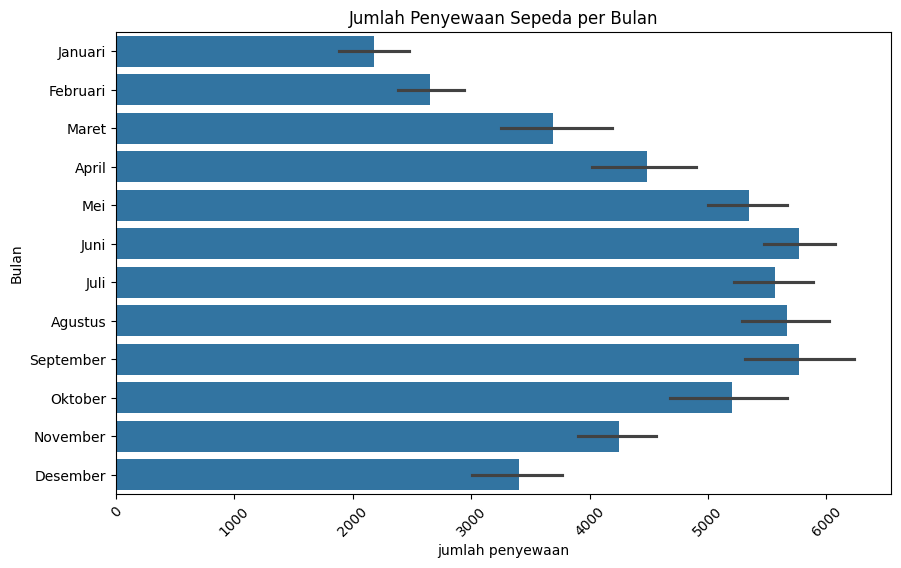

In [271]:
df_day['mnth'] = df_day['mnth'].map({
    1:'Januari', 2:'Februari', 3:'Maret', 4:'April',
    5:'Mei', 6:'Juni', 7:'Juli', 8:'Agustus',
    9:'September', 10:'Oktober', 11:'November', 12:'Desember'
})

plt.figure(figsize=(10, 6))
sns.barplot(x='cnt', y='mnth', data=df_day, order=['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember'])
plt.title('Jumlah Penyewaan Sepeda per Bulan')
plt.xlabel('jumlah penyewaan')
plt.ylabel('Bulan')
plt.xticks(rotation=45)
plt.show()

### Pertanyaan 2:

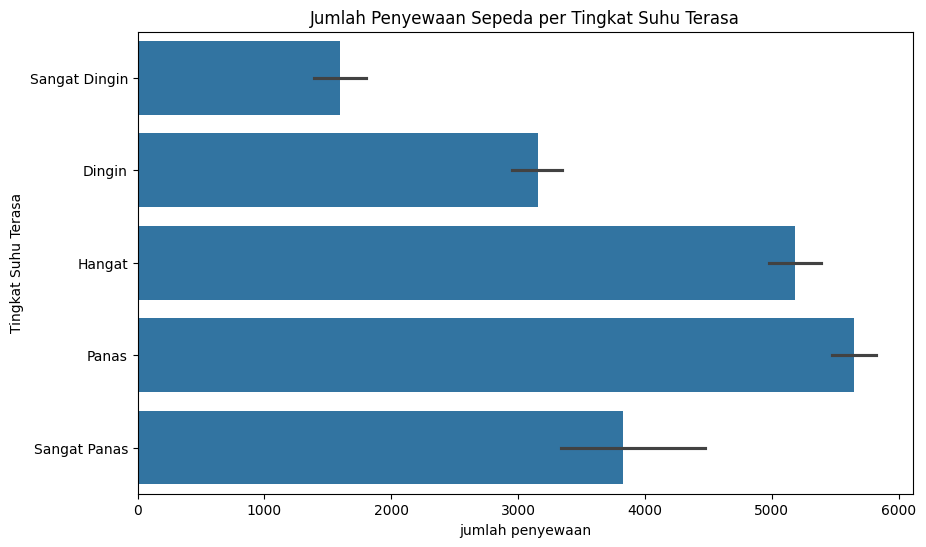

In [272]:
atemp_labels = ['Sangat Dingin','Dingin','Hangat','Panas','Sangat Panas']
df_day['atemp_category'] = pd.cut(df_day['atemp']*50,
  bins=[0, 10, 20, 30, 40, 50],
  labels=atemp_labels)

plt.figure(figsize=(10, 6))
sns.barplot(x='cnt', y='atemp_category', data=df_day, order=atemp_labels)
plt.title('Jumlah Penyewaan Sepeda per Tingkat Suhu Terasa')
plt.xlabel('jumlah penyewaan')
plt.ylabel('Tingkat Suhu Terasa')
plt.show()

**Insight:** (Opsional)
- Pertanyaan 1:Dari visualisasi jumlah penyewaan sepeda tertinggi di bulan september sedangkan terendah dibulan januari
- pertanyaan 2:dari visualisasi jumlah penyewaan berdasarkan suhu yang dirasakan oleh tubuh yaitu pada tingkatan panas

- suhu:
  - 0-9   : sangat dingin
  - 10-19 : dingin
  - 20-29 : hangat
  - 30-39 : Panas
  - 40-50 : sangat Panas


## Analisis Lanjutan (Opsional)

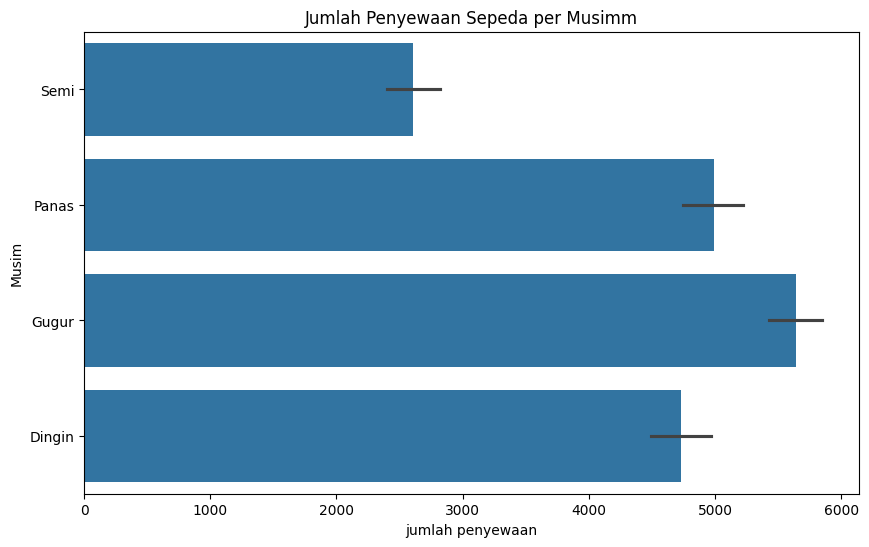

In [273]:
df_day['season'] = df_day['season'].map({
    1:'Semi', 2:'Panas', 3:'Gugur', 4:'Dingin'
})

plt.figure(figsize=(10, 6))
sns.barplot(x='cnt', y='season', data=df_day, order=['Semi', 'Panas', 'Gugur', 'Dingin'])
plt.title('Jumlah Penyewaan Sepeda per Musimm')
plt.xlabel('jumlah penyewaan')
plt.ylabel('Musim')
plt.show()

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** berdasarkan data yang sudah eksplor penyewaan sepeda lebih tinggi di bulan september jika di korelasikan dengan data musim yaitu bertepatan pada akhir musim gugur

- **Conclusion pertanyaan 2:** berdasarkan data yang sudah eksplor pengaruh suhu yang dirasakan tubuh terhadap penyewaan sepeda bahwa penyewaan terbanyak terjadi pada tingkatan panas yang dimana jika dimusimkan yaitu di musim panas dan gugur dan pada saat bulan akhir april sampai akhir september

**Rekomendasi Action Item:**
- tambahkan penyewaan jaket pada musim dingin agar tubuh pelanggan tetap hangat sekaligus membuka warung yang menjual makanan maupun minuman hangat pada agar pelanggan merasa nyaman

- dari action tersebut selain menambah bidang usaha semua sesuai pertimbangan karena banyaknya yang menyewa sepeda perharinya pada saat suhu terasa panas yaitu sekitar 6 bulan dimana keuntungan akan panen pada bulan akhir april sampai akhir september